In [243]:
## in terminal after creating a virtual env
# pip install --upgrade pip
# pip --version
# pip install numpy matplotlib pandas scikit-learn seaborn

In [244]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Read files and understand data

In [245]:
# trainingset

x1_train = pd.read_csv("/Users/kellyt/Documents/ml/HW2/train1_icu_data.csv")
y1_train = pd.read_csv("/Users/kellyt/Documents/ml/HW2/train1_icu_label.csv")

In [246]:
x1_train.head()

,age,bmi,elective_surgery,height,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,arf_apache,bun_apache,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,74.0,29.681633,0,175.0,0.184722,90.90,108.0,203.01,0.0,26.0,...,0,0,0,0,0,0,1,0,0,0
1,48.0,37.521259,0,168.0,1.993056,105.90,113.0,501.05,0.0,40.0,...,1,0,0,0,0,0,0,0,0,0
2,38.0,21.300161,0,165.1,0.370833,58.06,304.0,301.01,0.0,34.0,...,0,1,0,0,0,0,0,0,0,0
3,84.0,20.792690,0,154.9,0.306944,49.89,113.0,502.01,0.0,34.0,...,1,0,0,0,0,0,0,0,0,0
4,58.0,29.161731,0,162.6,26.084722,77.10,301.0,410.01,0.0,14.0,...,0,0,0,0,1,0,0,0,0,0


In [247]:
x1_train.info()
x1_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 108 entries, age to apache_2_bodysystem_Undefined diagnoses
dtypes: float64(70), int64(38)
memory usage: 4.1 MB


,age,bmi,elective_surgery,height,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,arf_apache,bun_apache,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,64.935800,28.849538,0.12300,169.742832,0.989392,83.112214,170.798000,505.485354,0.037200,30.725820,...,0.479000,0.105400,0.008000,0.053800,0.12280,0.021400,0.145200,0.038000,0.004000,0.022400
std,15.886666,8.494669,0.32847,10.750285,2.737740,25.492755,82.258106,426.524105,0.189271,23.116538,...,0.499609,0.307099,0.089093,0.225645,0.32824,0.144728,0.352338,0.191215,0.063125,0.147995
min,16.000000,14.844926,0.00000,137.200000,-0.224306,38.600000,101.000000,101.010000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,23.139163,0.00000,162.600000,0.025000,65.600000,113.000000,203.010000,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,67.000000,27.270146,0.00000,170.200000,0.125000,79.500000,117.500000,406.020000,0.000000,23.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,77.000000,32.858638,0.00000,177.800000,0.413889,96.200000,301.000000,601.060000,0.000000,39.000000,...,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,67.814990,1.00000,195.590000,46.949306,186.000000,308.000000,2201.050000,1.000000,127.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [248]:
print("x1_train:", x1_train.shape)
print("y1_train:", y1_train.shape)

x1_train: (5000, 108)
y1_train: (5000, 1)


In [249]:
y1_train.value_counts(normalize=True)

hospital_death
1                 0.51
0                 0.49
Name: proportion, dtype: float64

In [250]:
# testset

x1_test = pd.read_csv("/Users/kellyt/Documents/ml/HW2/test1_icu_data.csv")
y1_test = pd.read_csv("/Users/kellyt/Documents/ml/HW2/test1_icu_label.csv")

In [251]:
x1_test.info()
x1_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Columns: 108 entries, age to apache_2_bodysystem_Undefined diagnoses
dtypes: float64(70), int64(38)
memory usage: 925.7 KB


,age,bmi,elective_surgery,height,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,arf_apache,bun_apache,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_Renal/Genitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
count,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,...,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000,1097.000000
mean,65.854148,28.849181,0.150410,169.770474,0.932759,83.113573,177.428441,521.559453,0.035552,31.842571,...,0.487694,0.105743,0.010027,0.040109,0.130356,0.028259,0.131267,0.041933,0.002735,0.021878
std,15.507788,8.164014,0.357636,10.601599,3.233193,24.599020,84.037773,444.022544,0.185254,24.475257,...,0.500077,0.307649,0.099679,0.196305,0.336848,0.165787,0.337846,0.200526,0.052247,0.146351
min,16.000000,14.844926,0.000000,137.200000,-0.123611,38.600000,101.000000,101.010000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,57.000000,23.233456,0.000000,162.600000,0.018750,65.700000,113.000000,202.010000,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68.000000,27.287440,0.000000,170.100000,0.131250,80.000000,119.000000,407.010000,0.000000,24.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,78.000000,32.666667,0.000000,177.800000,0.399306,97.400000,301.000000,602.210000,0.000000,41.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,67.814990,1.000000,195.590000,64.948611,186.000000,308.000000,2201.050000,1.000000,127.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [252]:
y1_test.info()
y1_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   hospital_death  1097 non-null   int64
dtypes: int64(1)
memory usage: 8.7 KB


,hospital_death
count,1097.000000
mean,0.498633
std,0.500226
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [253]:
print("x1_test:", x1_test.shape)
print("y1_test:", y1_test.shape)

x1_test: (1097, 108)
y1_test: (1097, 1)


In [254]:
y1_test.value_counts(normalize=True)

hospital_death
0                 0.501367
1                 0.498633
Name: proportion, dtype: float64

In [255]:
# check for missing values
missing_x1_train = x1_train.isnull().sum()
missing_x1_test = x1_test.isnull().sum()
missing_y1_train = y1_train.isnull().sum()
missing_y1_test = y1_test.isnull().sum()

print(missing_x1_train[missing_x1_train > 0].sort_values(ascending=False))
print(missing_x1_test[missing_x1_test > 0].sort_values(ascending=False))
print(missing_y1_train[missing_y1_train > 0].sort_values(ascending=False))
print(missing_y1_test[missing_y1_test > 0].sort_values(ascending=False))

# no missing values yeahh

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


# Build the logistic regression model

In [256]:
# select feature columns
# feature_cols = ["age", "bmi", "height", "weight", "d1_heartrate_max", "d1_heartrate_min", "d1_mbp_max", "d1_mbp_min"]
# wanted to remove columns that started with "enthnicity_" but research show that it plays a factor: https://www.clinician.com/articles/do-race-and-ethnicity-affect-the-likelihood-of-icu-admission
feature_cols = x1_train.columns
X_train = x1_train[feature_cols]
y_train = y1_train.iloc[:, 0]

X_test = x1_test[feature_cols]
y_test = y1_test.iloc[:, 0]

In [257]:
# build the model
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# model = LogisticRegression(random_state=42, max_iter=1000)
# ---- Done by AI ----
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        random_state=42,
        max_iter=5000,
        # C=0.1 / 10 # no improvement when added
    ))
])
# --------------

# model.fit(x1_train,y1_train)
model.fit(X_train, y_train)

# run model on test data
# y_pred = model.predict(x1_test)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kellyt/Documents/ml/.venv-local/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  g

In [258]:
y_train_pred

array([1, 1, 1, ..., 1, 1, 0])

In [259]:
y_test_pred

array([0, 0, 0, ..., 1, 1, 1])

In [260]:
y_test_prob

array([0.02005908, 0.29330685, 0.1771858 , ..., 0.76650243, 0.94771806,
       0.64451676])

# Model Performance

In [261]:
print("=====Training Performance=====")
print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred), 3))
print("Recall   :", round(recall_score(y_train, y_train_pred), 3))
print("F1-score :", round(f1_score(y_train, y_train_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_train, y_train_prob), 3))
print(classification_report(y_train, y_train_pred, target_names=["Survived", "Dead"]))

print("\n=====Test Performance=====")
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 3))
print("Recall   :", round(recall_score(y_test, y_test_pred), 3))
print("F1-score :", round(f1_score(y_test, y_test_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_test_prob), 3))
print(classification_report(y_test, y_test_pred, target_names=["Survived", "Dead"]))

=====Training Performance=====
Training Accuracy: 0.797
Recall   : 0.793
F1-score : 0.799
ROC-AUC  : 0.884
              precision    recall  f1-score   support

    Survived       0.79      0.80      0.79      2450
        Dead       0.81      0.79      0.80      2550

    accuracy                           0.80      5000
   macro avg       0.80      0.80      0.80      5000
weighted avg       0.80      0.80      0.80      5000


=====Test Performance=====
Test Accuracy: 0.789
Recall   : 0.77
F1-score : 0.784
ROC-AUC  : 0.872
              precision    recall  f1-score   support

    Survived       0.78      0.81      0.79       550
        Dead       0.80      0.77      0.78       547

    accuracy                           0.79      1097
   macro avg       0.79      0.79      0.79      1097
weighted avg       0.79      0.79      0.79      1097



In [262]:
# model = LogisticRegression(random_state=42, max_iter=1000)

# =====Training Performance=====
# Training Accuracy: 0.791
# Recall   : 0.789
# F1-score : 0.794
# ROC-AUC  : 0.791
#               precision    recall  f1-score   support

#     Survived       0.78      0.79      0.79      2450
#         Dead       0.80      0.79      0.79      2550

#     accuracy                           0.79      5000
#    macro avg       0.79      0.79      0.79      5000
# weighted avg       0.79      0.79      0.79      5000


# =====Test Performance=====
# Test Accuracy: 0.78
# Recall   : 0.771
# F1-score : 0.778
# ROC-AUC  : 0.872
#               precision    recall  f1-score   support

#     Survived       0.78      0.79      0.78       550
#         Dead       0.78      0.77      0.78       547

#     accuracy                           0.78      1097
#    macro avg       0.78      0.78      0.78      1097
# weighted avg       0.78      0.78      0.78      1097

In [263]:
# model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("logreg", LogisticRegression(
#         random_state=42,
#         max_iter=5000,
#     ))
# ])

# =====Training Performance=====
# Training Accuracy: 0.797
# Recall   : 0.793
# F1-score : 0.799
# ROC-AUC  : 0.884
#               precision    recall  f1-score   support

#     Survived       0.79      0.80      0.79      2450
#         Dead       0.81      0.79      0.80      2550

#     accuracy                           0.80      5000
#    macro avg       0.80      0.80      0.80      5000
# weighted avg       0.80      0.80      0.80      5000


# =====Test Performance=====
# Test Accuracy: 0.789
# Recall   : 0.77
# F1-score : 0.784
# ROC-AUC  : 0.872
#               precision    recall  f1-score   support

#     Survived       0.78      0.81      0.79       550
#         Dead       0.80      0.77      0.78       547

#     accuracy                           0.79      1097
#    macro avg       0.79      0.79      0.79      1097
# weighted avg       0.79      0.79      0.79      1097

In [264]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
print(cnf_matrix)

[[444 106]
 [126 421]]


# Plot ROC Curve

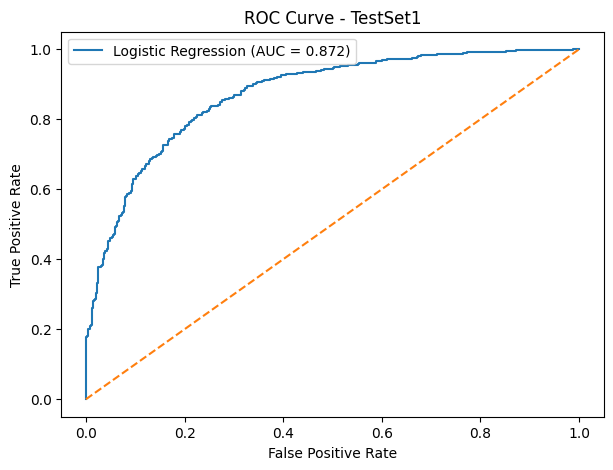

In [265]:
# ROC curve on test data for better understanding
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TestSet1")
plt.legend()
plt.show()